In [12]:
import pandas as pd
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

url = 'https://github.com/brunopless/TFM-Equipo-4-BDDS/raw/main/entrega-3/2024_08_23_Consolidado_BCN.xlsx'
data = pd.read_excel(url)

lat_col = 'latitude'
lon_col = 'longitude'

In [13]:
# Aplicar KMeans para 25 clusters
n_clusters = 25
kmeans = KMeans(n_clusters=n_clusters, random_state=42)

# Ajustar el modelo solo con las columnas de latitud y longitud
data['cluster'] = kmeans.fit_predict(data[[lat_col, lon_col]])

# Ver los resultados de los clusters
print(data[['cluster', lat_col, lon_col]].head())

   cluster   latitude  longitude
0       14  41.383719   2.175998
1       24  41.397182   2.142885
2        0  41.405040   2.211389
3       16  41.267389   2.032712
4        0  41.408746   2.215716


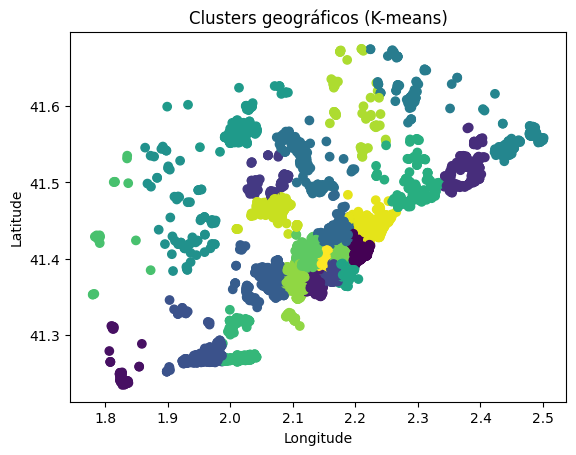

In [14]:
# Visualizar los clusters
plt.scatter(data[lon_col], data[lat_col], c=data['cluster'], cmap='viridis')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Clusters geográficos (K-means)')
plt.show()

In [15]:
from sklearn.preprocessing import OneHotEncoder

# Aplicar One-Hot Encoding a la columna 'cluster'
encoder = OneHotEncoder(sparse_output=False)
cluster_encoded = encoder.fit_transform(data[['cluster']])
cluster_encoded_df = pd.DataFrame(cluster_encoded, columns=[f'cluster_{int(i)}' for i in range(n_clusters)])
cluster_encoded_df = cluster_encoded_df.drop(cluster_encoded_df.columns[-1], axis=1)
data = pd.concat([data, cluster_encoded_df], axis=1)

print(data.head())

   index  Fecha extraccion floor  price propertyType operation   size  \
0      1           1052024     4    749    penthouse      rent   45.0   
1      2           1052024     2   4400         flat      rent  170.0   
2      3           1052024     5   1700         flat      rent   74.0   
3      4           1052024     3   4500         flat      rent   59.0   
4      5           1052024     1   2369         flat      rent  127.0   

   exterior  rooms  bathrooms  ... cluster_14 cluster_15 cluster_16  \
0       1.0    1.0        1.0  ...        1.0        0.0        0.0   
1       1.0    3.0        4.0  ...        0.0        0.0        0.0   
2       1.0    2.0        1.0  ...        0.0        0.0        0.0   
3       1.0    1.0        1.0  ...        0.0        0.0        1.0   
4       1.0    2.0        2.0  ...        0.0        0.0        0.0   

  cluster_17 cluster_18 cluster_19  cluster_20  cluster_21 cluster_22  \
0        0.0        0.0        0.0         0.0         0.0   

In [16]:
output_file = '2024_09_25_Clusters_BCN.csv'
data.to_csv(output_file, index=False)

from google.colab import files
files.download(output_file)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>